<a href="https://colab.research.google.com/github/NavdeeepSinghh/Deep_Learning_TImeSeries/blob/main/Deep_Learning_Timeseriest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 📦 CELL 1 — Install & Imports

In [1]:
!pip install torch numpy pandas matplotlib scikit-learn yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf

#⚙️ 📌 CELL 2 — Personalized Parameters

In [3]:
roll_number = "102303787"

digits = [int(d) for d in roll_number]

window_size = (sum(digits) % 10) + 8
prediction_horizon = (int(roll_number[-2:]) % 3) + 1
hidden_size = (int(roll_number[:3]) % 16) + 8

print(window_size, prediction_horizon, hidden_size)

9 1 14


#📊 📌 CELL 3 — Load Dataset

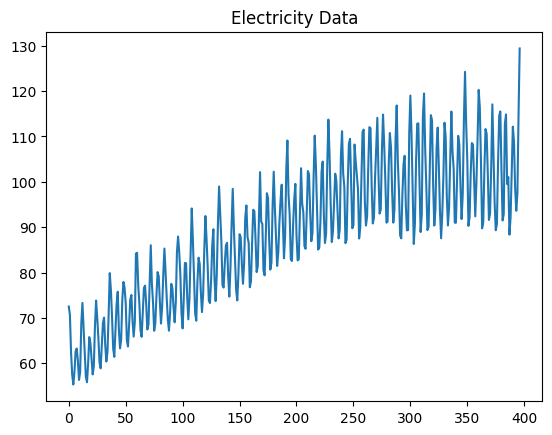

In [6]:
df = pd.read_csv("/content/Electric_Production.csv.xls")

# WHY: we only use numeric values, models learn patterns from numbers
data1 = df.iloc[:, 1].values

plt.plot(data1)
plt.title("Electricity Data")
plt.show()

/tmp/ipykernel_1380/653775110.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_stock = yf.download("AAPL", start="2015-01-01")["Close"].values
[*********************100%***********************]  1 of 1 completed


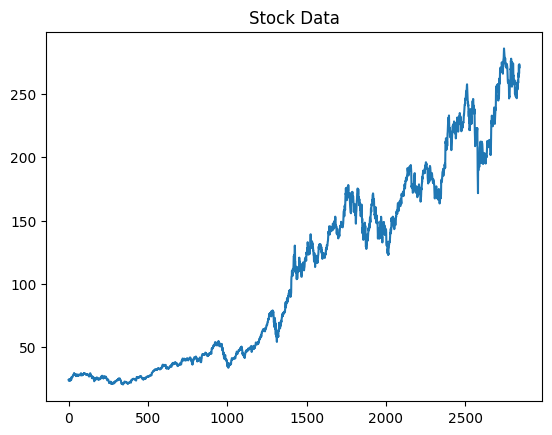

In [7]:
# Using Apple stock as second real-world dataset
data_stock = yf.download("AAPL", start="2015-01-01")["Close"].values

plt.plot(data_stock)
plt.title("Stock Data")
plt.show()

#🔄 📌 CELL 4 — Normalization

In [8]:
def normalize(data):
    scaler = MinMaxScaler()
    return scaler.fit_transform(data.reshape(-1,1)).flatten(), scaler

data1, scaler1 = normalize(data1)
data_stock, scaler2 = normalize(data_stock)

#🔁 📌 CELL 5 — Windowing Function (CORE)

In [9]:
# WHY: converts time series → supervised learning
def create_sequences(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

#✂️ 📌 CELL 6 — Train/Test Split (Chronological)

In [10]:
def prepare_data(data):
    X, y = create_sequences(data, window_size, prediction_horizon)

    split = int(0.8 * len(X))  # chronological split

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )

#🧱 📌 CELL 7 — MLP Model

In [11]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(window_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, prediction_horizon)
        )

    def forward(self, x):
        # WHY: MLP treats sequence as flat vector (no time awareness)
        return self.model(x)

#🔁 📌 CELL 8 — Custom GRU

In [12]:
class CustomGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = hidden_size

        self.update = nn.Linear(1 + hidden_size, hidden_size)
        self.reset = nn.Linear(1 + hidden_size, hidden_size)
        self.candidate = nn.Linear(1 + hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        # WHY: hidden state stores past memory
        h = torch.zeros(x.size(0), hidden_size)

        for t in range(x.size(1)):
            xt = x[:, t].unsqueeze(1)

            combined = torch.cat([xt, h], dim=1)

            z = torch.sigmoid(self.update(combined))  # update gate
            r = torch.sigmoid(self.reset(combined))   # reset gate

            combined_r = torch.cat([xt, r*h], dim=1)
            h_tilde = torch.tanh(self.candidate(combined_r))

            # WHY: decides what to remember vs forget
            h = (1 - z) * h + z * h_tilde

        return self.fc(h)

#🧠 📌 CELL 10 — LSTM (Prebuilt)

In [13]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

#⚡ 📌 CELL 11 — Transformer

In [14]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(1, hidden_size)

        encoder = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=2)
        self.transformer = nn.TransformerEncoder(encoder, num_layers=2)

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embed(x)
        x = x.permute(1,0,2)
        out = self.transformer(x)
        return self.fc(out[-1])

#🏋️ 📌 CELL 12 — Training Function

In [15]:
def train_model(model, X, y, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        print(f"Epoch {epoch}: {loss.item()}")

    return losses

#▶️ 📌 CELL 13 — Train Models

In [16]:
def evaluate(model, X_test, y_test):
    pred = model(X_test).detach().numpy()
    true = y_test.numpy()

    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)

    print("MSE:", mse)
    print("MAE:", mae)
    print("RMSE:", rmse)

    return pred, true

#📊 📌 CELL 15 — Plot

In [17]:
def plot_results(true, pred, title):
    plt.figure(figsize=(10,4))
    plt.plot(true[:100], label="Actual")
    plt.plot(pred[:100], label="Predicted")
    plt.legend()
    plt.title(title)
    plt.show()

#🧪 📌 CELL 16 — Ablation Study


--- Electricity Dataset ---
Epoch 0: 0.10816004872322083
Epoch 1: 0.10407242178916931
Epoch 2: 0.10008860379457474
Epoch 3: 0.09620942920446396
Epoch 4: 0.09243590384721756
Epoch 5: 0.08876876533031464
Epoch 6: 0.08520833402872086
Epoch 7: 0.0817544162273407
Epoch 8: 0.07840640097856522
Epoch 9: 0.07516338676214218


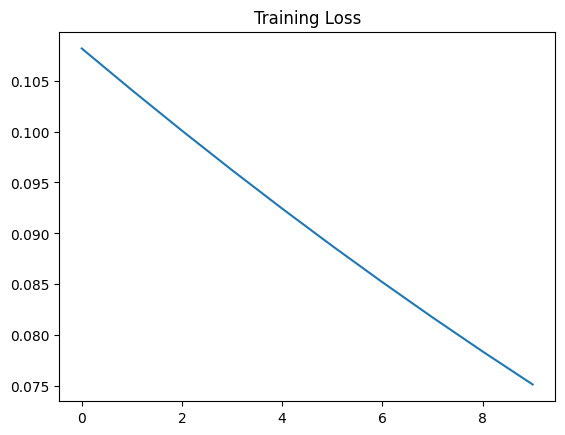

MSE: 0.16478268802165985
MAE: 0.3868834674358368
RMSE: 0.4059343395447838


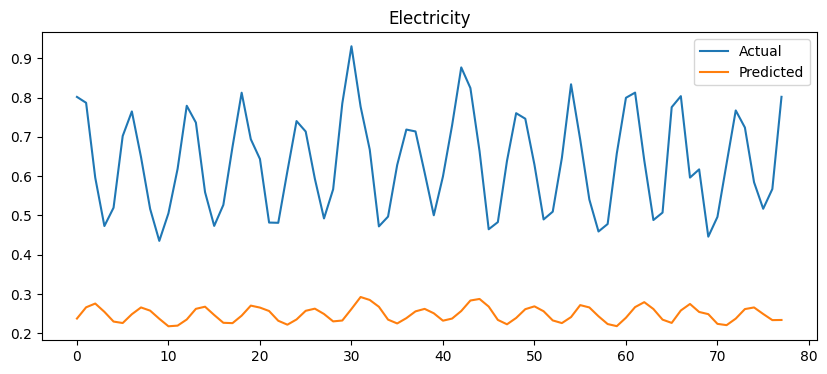


--- Stock Dataset ---
Epoch 0: 0.13130146265029907
Epoch 1: 0.12771520018577576
Epoch 2: 0.12420807778835297
Epoch 3: 0.12078031152486801
Epoch 4: 0.11743103712797165
Epoch 5: 0.11415853351354599
Epoch 6: 0.11096135526895523
Epoch 7: 0.10783863067626953
Epoch 8: 0.10478989034891129
Epoch 9: 0.10181477665901184


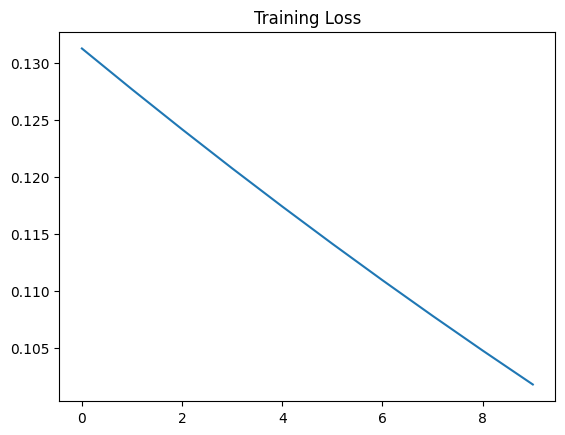

MSE: 0.5957394242286682
MAE: 0.7635769248008728
RMSE: 0.7718415797485053


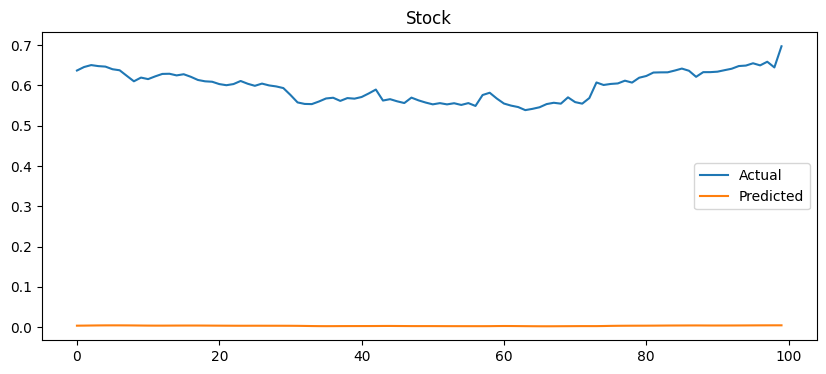

In [19]:
for dataset, name in [(data1, "Electricity"), (data_stock, "Stock")]:

    print(f"\n--- {name} Dataset ---")

    X_train, y_train, X_test, y_test = prepare_data(dataset)

    model = CustomGRU() if int(roll_number[-1])%2 else CustomGRU()
    losses = train_model(model, X_train, y_train)

    plt.plot(losses)
    plt.title("Training Loss")
    plt.show()

    pred, true = evaluate(model, X_test, y_test)
    plot_results(true, pred, name)

In [20]:
for w in [window_size//2, window_size, window_size*2]:
    print("\nWindow Size:", w)

    X, y = create_sequences(data1, w, prediction_horizon)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    model = CustomGRU()
    train_model(model, X, y, epochs=5)


Window Size: 4
Epoch 0: 0.33472341299057007
Epoch 1: 0.3277898132801056
Epoch 2: 0.320923775434494
Epoch 3: 0.31412672996520996
Epoch 4: 0.3073996603488922

Window Size: 9
Epoch 0: 0.39937594532966614
Epoch 1: 0.3906698226928711
Epoch 2: 0.38205957412719727
Epoch 3: 0.3735376000404358
Epoch 4: 0.36509570479393005

Window Size: 18
Epoch 0: 0.32060936093330383
Epoch 1: 0.3144536018371582
Epoch 2: 0.30837464332580566
Epoch 3: 0.3023684322834015
Epoch 4: 0.29642435908317566
